# Data & Evaluation Pipeline Demo

This notebook walks through the shared Flickr30k data pipeline end-to-end:
1. Load configuration
2. Parse captions
3. Inspect train/val/test splits
4. Explore the vocabulary
5. Preview batches from the DataLoader
6. Visualize sample images with captions
7. Run evaluation metrics

In [1]:
import sys
from pathlib import Path

# Make sure the repo root is on the Python path
REPO_ROOT = Path(".").resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\tochi\OneDrive\Documents\georgia_tech_omscs\deeplearning\final_project\deeplearning-project


## 1. Load Configuration

In [2]:
import json
from src.project_config import load_project_config, get_config_value, get_image_size, get_image_normalization

config = load_project_config(REPO_ROOT / "configs/data_config.example.json")
print(json.dumps(config, indent=2))

{
  "captions_path": "data/captions.txt",
  "images_dir": "data/Images",
  "splits_dir": "metadata/splits",
  "vocab_dir": "metadata/vocab",
  "references_example_path": "configs/references.example.json",
  "predictions_example_path": "configs/predictions.example.json",
  "seed": 42,
  "train_ratio": 0.8,
  "val_ratio": 0.1,
  "test_ratio": 0.1,
  "min_word_freq": 5,
  "max_caption_length": 40,
  "image_size": [
    224,
    224
  ],
  "image_normalization": {
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  },
  "special_tokens": {
    "pad": "<pad>",
    "start": "<start>",
    "end": "<end>",
    "unk": "<unk>"
  }
}


In [3]:
# Extract key settings
captions_path = REPO_ROOT / get_config_value(config, "captions_path", "data/captions.txt")
images_dir = REPO_ROOT / get_config_value(config, "images_dir", "data/Images")
splits_dir = REPO_ROOT / get_config_value(config, "splits_dir", "metadata/splits")
vocab_dir = REPO_ROOT / get_config_value(config, "vocab_dir", "metadata/vocab")
image_size = get_image_size(config)
image_mean, image_std = get_image_normalization(config)

print(f"Captions:  {captions_path}")
print(f"Images:    {images_dir}")
print(f"Splits:    {splits_dir}")
print(f"Vocab:     {vocab_dir}")
print(f"Image size: {image_size}")
print(f"Normalize:  mean={image_mean}, std={image_std}")

Captions:  C:\Users\tochi\OneDrive\Documents\georgia_tech_omscs\deeplearning\final_project\deeplearning-project\data\captions.txt
Images:    C:\Users\tochi\OneDrive\Documents\georgia_tech_omscs\deeplearning\final_project\deeplearning-project\data\Images
Splits:    C:\Users\tochi\OneDrive\Documents\georgia_tech_omscs\deeplearning\final_project\deeplearning-project\metadata\splits
Vocab:     C:\Users\tochi\OneDrive\Documents\georgia_tech_omscs\deeplearning\final_project\deeplearning-project\metadata\vocab
Image size: (224, 224)
Normalize:  mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)


## 2. Parse Captions

In [4]:
from src.data.splits import load_caption_map

caption_map = load_caption_map(captions_path)

num_images = len(caption_map)
num_captions = sum(len(v) for v in caption_map.values())
captions_per_image = set(len(v) for v in caption_map.values())

print(f"Total images:  {num_images}")
print(f"Total captions: {num_captions}")
print(f"Captions per image: {captions_per_image}")

Total images:  31783
Total captions: 158915
Captions per image: {5}


In [5]:
# Preview captions for a sample image
sample_id = list(caption_map.keys())[0]
print(f"Image: {sample_id}")
for i, cap in enumerate(caption_map[sample_id]):
    print(f"  [{i}] {cap}")

Image: 1000092795.jpg
  [0] Two young guys with shaggy hair look at their hands while hanging out in the yard .
  [1] Two young , White males are outside near many bushes .
  [2] Two men in green shirts are standing in a yard .
  [3] A man in a blue shirt standing in a garden .
  [4] Two friends enjoy time spent together .


## 3. Caption Preprocessing

In [6]:
from src.data.preprocess import normalize_caption, tokenize_caption, truncate_tokens

raw = caption_map[sample_id][0]
print(f"Raw:        {repr(raw)}")
print(f"Normalized: {repr(normalize_caption(raw))}")
print(f"Tokenized:  {tokenize_caption(raw)}")
print(f"Truncated (max_length=10): {truncate_tokens(tokenize_caption(raw), max_length=10)}")

Raw:        'Two young guys with shaggy hair look at their hands while hanging out in the yard .'
Normalized: 'two young guys with shaggy hair look at their hands while hanging out in the yard .'
Tokenized:  ['two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at', 'their', 'hands', 'while', 'hanging', 'out', 'in', 'the', 'yard', '.']
Truncated (max_length=10): ['two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at']


## 4. Inspect Splits

In [7]:
from src.data.splits import load_split_file

train_ids = load_split_file(splits_dir / "train.txt")
val_ids = load_split_file(splits_dir / "val.txt")
test_ids = load_split_file(splits_dir / "test.txt")

print(f"Train: {len(train_ids)} images")
print(f"Val:   {len(val_ids)} images")
print(f"Test:  {len(test_ids)} images")
print(f"Total: {len(train_ids) + len(val_ids) + len(test_ids)} images")

# Verify no overlap
train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)
print(f"\nOverlap train/val:  {len(train_set & val_set)}")
print(f"Overlap train/test: {len(train_set & test_set)}")
print(f"Overlap val/test:   {len(val_set & test_set)}")

Train: 25426 images
Val:   3178 images
Test:  3179 images
Total: 31783 images

Overlap train/val:  0
Overlap train/test: 0
Overlap val/test:   0


## 5. Explore the Vocabulary

In [8]:
from src.data.vocab import Vocabulary

vocab = Vocabulary.load(vocab_dir / "flickr30k_vocab.json")

print(f"Vocabulary size: {len(vocab.word2idx)}")
print(f"\nSpecial tokens:")
for token in ["<pad>", "<start>", "<end>", "<unk>"]:
    print(f"  {token} -> {vocab.word2idx[token]}")

# Show some regular words
print(f"\nSample words (indices 4-13):")
for idx in range(4, 14):
    print(f"  {idx} -> {vocab.idx2word[idx]}")

Vocabulary size: 7013

Special tokens:
  <pad> -> 0
  <start> -> 1
  <end> -> 2
  <unk> -> 3

Sample words (indices 4-13):
  4 -> !
  5 -> "
  6 -> $
  7 -> %
  8 -> &
  9 -> '
  10 -> 'll
  11 -> 'm
  12 -> 're
  13 -> 's


In [9]:
# Encode and decode a caption
tokens = tokenize_caption(caption_map[sample_id][0])
encoded = vocab.encode(tokens)
decoded = vocab.decode(encoded)

print(f"Tokens:  {tokens}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Tokens:  ['two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at', 'their', 'hands', 'while', 'hanging', 'out', 'in', 'the', 'yard', '.']
Encoded: [6540, 6993, 2763, 6910, 5335, 2773, 3559, 321, 6255, 2815, 6852, 2821, 4144, 3074, 6253, 6976, 18]
Decoded: ['two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at', 'their', 'hands', 'while', 'hanging', 'out', 'in', 'the', 'yard', '.']


## 6. Preview DataLoader Batches

In [10]:
from src.data.dataset import create_caption_dataloader, DEFAULT_IMAGE_SIZE

# Create a small dataloader from the first few training images
dataloader = create_caption_dataloader(
    captions_path=captions_path,
    images_dir=images_dir,
    split_image_ids=train_ids[:8],
    vocab=vocab,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    max_caption_length=40,
    image_size=DEFAULT_IMAGE_SIZE[0],
)

print(f"Dataset size: {len(dataloader.dataset)} samples")
print(f"Number of batches: {len(dataloader)}")

Dataset size: 40 samples
Number of batches: 10


In [11]:
# Inspect the first batch
batch = next(iter(dataloader))

print("Batch keys:", list(batch.keys()))
print(f"\nimages shape:       {batch['images'].shape}")
print(f"caption_ids shape:  {batch['caption_ids'].shape}")
print(f"target_ids shape:   {batch['target_ids'].shape}")
print(f"padding_mask shape: {batch['padding_mask'].shape}")
print(f"lengths:            {batch['lengths'].tolist()}")
print(f"\nImage pixel range: [{batch['images'].min():.4f}, {batch['images'].max():.4f}]")

Batch keys: ['images', 'image_ids', 'caption_texts', 'caption_ids', 'target_ids', 'padding_mask', 'lengths']

images shape:       torch.Size([4, 3, 224, 224])
caption_ids shape:  torch.Size([4, 17])
target_ids shape:   torch.Size([4, 17])
padding_mask shape: torch.Size([4, 17])
lengths:            [17, 12, 11, 10]

Image pixel range: [-2.0837, 2.6400]


In [12]:
# Show image IDs and captions in the batch
for i in range(len(batch['image_ids'])):
    print(f"\n[{i}] {batch['image_ids'][i]}")
    print(f"    Caption: {batch['caption_texts'][i]}")
    print(f"    IDs:     {batch['caption_ids'][i][:batch['lengths'][i]].tolist()}")
    print(f"    Length:  {batch['lengths'][i].item()}")


[0] 3328495660.jpg
    Caption: One woman makes thread on a spindle while another woman braids a thirds hair .
    IDs:     [1, 4090, 6915, 3623, 6277, 4087, 61, 3, 6852, 212, 6915, 792, 61, 3, 2773, 18, 2]
    Length:  17

[1] 3328495660.jpg
    Caption: Two girls primping a third girl in village setting .
    IDs:     [1, 6540, 2598, 3, 61, 6270, 2596, 3074, 6684, 5313, 18, 2]
    Length:  12

[2] 3328495660.jpg
    Caption: Three people are setting inside a grass shelter .
    IDs:     [1, 6278, 4368, 257, 5313, 3112, 61, 2687, 5368, 18, 2]
    Length:  11

[3] 3328495660.jpg
    Caption: Three women sit together near woven walls .
    IDs:     [1, 6278, 6916, 5486, 6339, 3956, 6949, 6745, 18, 2]
    Length:  10


## 7. Visualize Sample Images with Captions

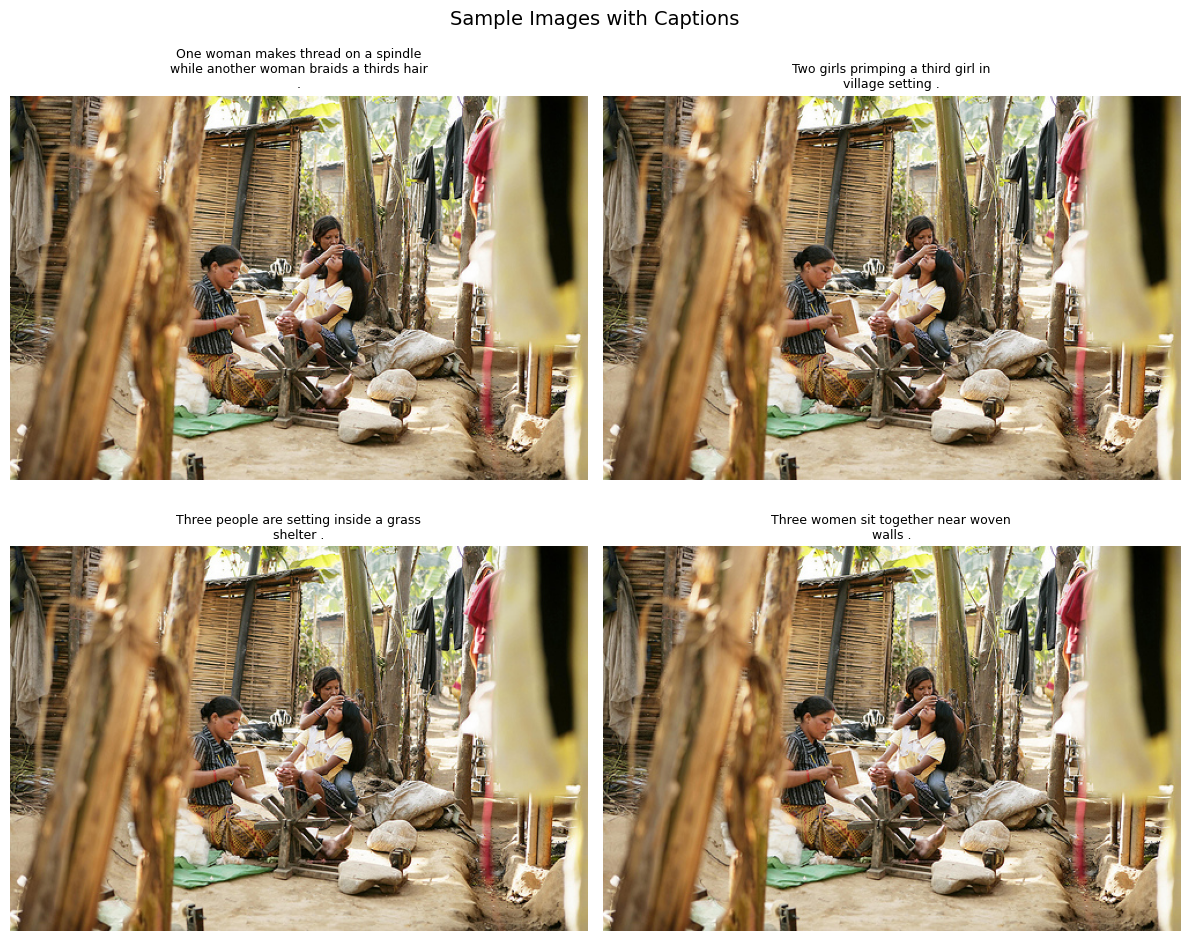

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import textwrap

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image_id = batch['image_ids'][i]
    img = Image.open(images_dir / image_id).convert('RGB')
    ax.imshow(img)
    caption = batch['caption_texts'][i]
    wrapped = textwrap.fill(caption, width=40)
    ax.set_title(wrapped, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Images with Captions', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Run Evaluation Metrics

In [14]:
from src.eval.metrics import evaluate_captions

# Load the example reference and prediction files
with open(REPO_ROOT / "configs/references.example.json") as f:
    references = json.load(f)
with open(REPO_ROOT / "configs/predictions.example.json") as f:
    predictions = json.load(f)

print("References:")
for img_id, caps in references.items():
    print(f"  {img_id}: {len(caps)} captions")
    for c in caps:
        print(f"    - {c}")

print(f"\nPredictions:")
for img_id, cap in predictions.items():
    print(f"  {img_id}: {cap}")

References:
  1000092795.jpg: 5 captions
    - Two young guys with shaggy hair look at their hands while hanging out in the yard .
    - Two young White males are outside near many bushes .
    - Two men in green shirts are standing in a yard .
    - A man in a blue shirt standing in a garden .
    - Two friends enjoy time spent together .
  10002456.jpg: 2 captions
    - Several men in hard hats are operating a giant pulley system .
    - Workers look down from up above on a piece of equipment .

Predictions:
  1000092795.jpg: Two young men stand together in a yard .
  10002456.jpg: Several workers operate heavy equipment .


In [15]:
# Compute metrics
metrics = evaluate_captions(references, predictions)

print("Evaluation Metrics:")
print("-" * 30)
for name, value in metrics.items():
    print(f"  {name:>8s}: {value:.6f}")

Evaluation Metrics:
------------------------------
    bleu_1: 0.501671
    bleu_2: 0.347846
    bleu_3: 0.239836
    bleu_4: 0.176079
    meteor: 0.405926


## Summary

If all cells above ran without errors, the pipeline is working correctly:
- Config loading ✓
- Caption parsing ✓
- Preprocessing (normalize, tokenize, truncate) ✓
- Train/val/test splits (disjoint, full coverage) ✓
- Vocabulary (special tokens, encode/decode) ✓
- DataLoader (correct batch shapes, padding, masking) ✓
- Evaluation metrics (BLEU-1/2/3/4, METEOR) ✓